In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('merged_output.csv')

In [2]:
# Convert to datetime
df['CreatedOn'] = pd.to_datetime(df['CreatedOn'])

# Sort by date
df = df.sort_values(['district', 'CreatedOn'])

# Aggregate monthly pest counts
df['year_month'] = df['CreatedOn'].dt.to_period('M')

df_monthly = df.groupby(['district', 'year_month']).agg({
    'pest_count': 'sum',
    'latitude': 'first',
    'longitude': 'first'
}).reset_index()

# Convert period to timestamp
df_monthly['year_month'] = df_monthly['year_month'].dt.to_timestamp()

# Sort again
df_monthly = df_monthly.sort_values(['district', 'year_month'])

df_monthly.head()

,district,year_month,pest_count,latitude,longitude
0,24 PARGANAS (NORTH DISTRICT),2013-04-01,21,22.591967,88.39957
1,24 PARGANAS (NORTH DISTRICT),2013-05-01,24,22.591967,88.39957
2,24 PARGANAS (NORTH DISTRICT),2013-06-01,15,22.591967,88.39957
3,24 PARGANAS (NORTH DISTRICT),2013-07-01,14,22.591967,88.39957
4,24 PARGANAS (NORTH DISTRICT),2013-09-01,22,22.591967,88.39957


In [3]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

# Unique districts
district_coords = df_monthly[['district','latitude','longitude']].drop_duplicates().reset_index(drop=True)

coords = district_coords[['latitude','longitude']].values
num_nodes = len(coords)

print("Total districts:", num_nodes)

# Convert degrees → radians
coords_rad = np.radians(coords)

K = 8

nbrs = NearestNeighbors(
    n_neighbors=K+1,
    metric='haversine'
)

nbrs.fit(coords_rad)

distances, indices = nbrs.kneighbors(coords_rad)

# Convert radians → km
earth_radius = 6371
distances = distances * earth_radius

Total districts: 543


In [4]:
A = np.zeros((num_nodes, num_nodes))

for i in range(num_nodes):

    for j in range(1, K+1):  # skip self neighbor

        neighbor = indices[i][j]
        dist = distances[i][j]

        if dist == 0:
            continue

        weight = 1 / dist

        A[i, neighbor] = weight
        A[neighbor, i] = weight

print(A)

[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.01112117]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.01112117 ... 0.         0.         0.        ]]


In [5]:
import numpy as np
import torch

# Degree matrix
D = np.diag(A.sum(axis=1))

# Avoid divide by zero
D_inv_sqrt = np.linalg.inv(np.sqrt(D + 1e-8))

# Symmetric normalization
A_norm = D_inv_sqrt @ A @ D_inv_sqrt

A_norm = torch.tensor(A_norm, dtype=torch.float)

In [6]:
from torch_geometric.utils import dense_to_sparse

edge_index, edge_weight = dense_to_sparse(A_norm)

In [7]:
# Pivot to time x district matrix
pivot_df = df_monthly.pivot(index='year_month', 
                            columns='district', 
                            values='pest_count')

pivot_df = pivot_df.fillna(0)
pivot_df = pivot_df[district_coords['district']]

# Convert to numpy
X = pivot_df.values   # shape = (time_steps, districts)

# Normalize
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Add feature dimension
X_scaled = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

print(X_scaled.shape)

(57, 543, 1)


In [8]:
def create_sequences(data, seq_length=6):
    X_seq = []
    y_seq = []

    for i in range(len(data) - seq_length):
        X_seq.append(data[i:i+seq_length])
        y_seq.append(data[i+seq_length])

    return np.array(X_seq), np.array(y_seq)

seq_length = 6
X_seq, y_seq = create_sequences(X_scaled, seq_length)

print(X_seq.shape, y_seq.shape)

(51, 6, 543, 1) (51, 543, 1)


In [9]:
import torch
import torch.nn as nn
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import add_self_loops


class DistanceWeightedMPNN(MessagePassing):

    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='add')

        self.linear_neighbor = nn.Linear(in_channels, out_channels)
        self.linear_self = nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index, edge_weight):

        # Add self-loops
        edge_index, edge_weight = add_self_loops(
            edge_index,
            edge_attr=edge_weight,
            fill_value=1.0,
            num_nodes=x.size(0)
        )

        return self.propagate(edge_index, x=x, edge_weight=edge_weight)

    def message(self, x_j, edge_weight):

        # Weighted neighbor message
        return edge_weight.view(-1,1) * x_j

    def update(self, aggr_out, x):

        # Combine neighbor + self node features
        return self.linear_neighbor(aggr_out) + self.linear_self(x)

In [10]:
class SpatioTemporalMPNN(nn.Module):

    def __init__(self, num_nodes, in_channels, hidden_dim):
        super().__init__()

        self.mpnn1 = DistanceWeightedMPNN(in_channels, hidden_dim)
        self.mpnn2 = DistanceWeightedMPNN(hidden_dim, hidden_dim)

        self.lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, 1)

        self.num_nodes = num_nodes


    def forward(self, x_seq, edge_index, edge_weight):

        batch_size, seq_len, num_nodes, features = x_seq.shape

        spatial_outputs = []

        for t in range(seq_len):

            # Extract features at time t
            x_t = x_seq[:, t, :, :]       # (batch , nodes , features)

            x_t = x_t.reshape(batch_size*num_nodes, features)

            # Build batched edge index
            edge_index_batch = []

            for i in range(batch_size):

                offset = i * num_nodes

                edge_index_batch.append(edge_index + offset)

            edge_index_batch = torch.cat(edge_index_batch, dim=1).to(x_seq.device)

            edge_weight_batch = edge_weight.repeat(batch_size)

            # Spatial message passing
            h = self.mpnn1(x_t, edge_index_batch, edge_weight_batch)
            h = torch.relu(h)
            h = self.mpnn2(h, edge_index_batch, edge_weight_batch)

            h = h.reshape(batch_size, num_nodes, -1)

            spatial_outputs.append(h)

        x = torch.stack(spatial_outputs, dim=1)

        # shape: (batch , seq_len , nodes , hidden)

        x = x.permute(0,2,1,3)

        # shape: (batch , nodes , seq_len , hidden)

        x = x.reshape(batch_size*num_nodes, seq_len, -1)

        lstm_out,_ = self.lstm(x)

        final_out = lstm_out[:,-1,:]

        pred = self.fc(final_out)

        pred = pred.reshape(batch_size, num_nodes)

        return pred

In [11]:
# Chronological split (80% train, 20% test)

train_size = int(0.8 * len(X_seq))

X_train = X_seq[:train_size]
y_train = y_seq[:train_size]

X_test = X_seq[train_size:]
y_test = y_seq[train_size:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (40, 6, 543, 1)
Test shape: (11, 6, 543, 1)


In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train_tensor = torch.tensor(X_train, dtype=torch.float).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float).squeeze(-1).to(device)

X_test_tensor = torch.tensor(X_test, dtype=torch.float).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float).squeeze(-1).to(device)

In [13]:
model = SpatioTemporalMPNN(
    num_nodes=X_seq.shape[2],
    in_channels=1,
    hidden_dim=16
).to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=10
)

In [14]:

edge_index = edge_index.to(device)
edge_weight = edge_weight.to(device)

epochs = 250

train_losses = []

for epoch in range(epochs):
    print("Epoch running:", epoch)

    model.train()
    optimizer.zero_grad()

    output = model(X_train_tensor, edge_index, edge_weight)

    loss = criterion(output, y_train_tensor)

    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

    optimizer.step()

    scheduler.step(loss.item())
    train_losses.append(loss.item())   # ⭐ IMPORTANT LINE

    print(f"Epoch {epoch} | Train Loss: {loss.item():.4f}")

Epoch running: 0
Epoch 0 | Train Loss: 0.1849
Epoch running: 1
Epoch 1 | Train Loss: 0.1744
Epoch running: 2
Epoch 2 | Train Loss: 0.1643
Epoch running: 3
Epoch 3 | Train Loss: 0.1546
Epoch running: 4
Epoch 4 | Train Loss: 0.1453
Epoch running: 5
Epoch 5 | Train Loss: 0.1365
Epoch running: 6
Epoch 6 | Train Loss: 0.1280
Epoch running: 7
Epoch 7 | Train Loss: 0.1200
Epoch running: 8
Epoch 8 | Train Loss: 0.1125
Epoch running: 9
Epoch 9 | Train Loss: 0.1055
Epoch running: 10
Epoch 10 | Train Loss: 0.0990
Epoch running: 11
Epoch 11 | Train Loss: 0.0930
Epoch running: 12
Epoch 12 | Train Loss: 0.0876
Epoch running: 13
Epoch 13 | Train Loss: 0.0827
Epoch running: 14
Epoch 14 | Train Loss: 0.0784
Epoch running: 15
Epoch 15 | Train Loss: 0.0747
Epoch running: 16
Epoch 16 | Train Loss: 0.0715
Epoch running: 17
Epoch 17 | Train Loss: 0.0688
Epoch running: 18
Epoch 18 | Train Loss: 0.0666
Epoch running: 19
Epoch 19 | Train Loss: 0.0649
Epoch running: 20
Epoch 20 | Train Loss: 0.0636
Epoch runnin

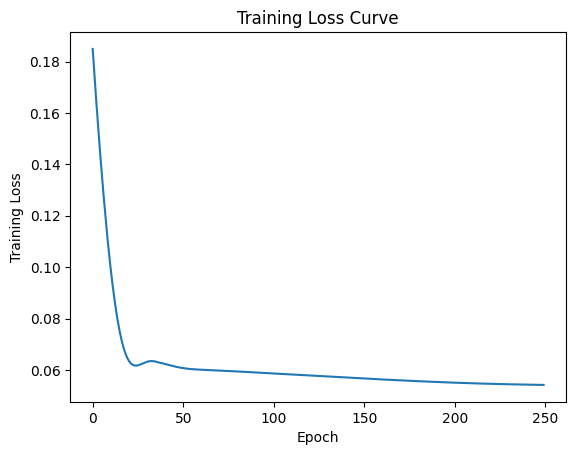

In [15]:
import matplotlib.pyplot as plt

plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.show()

In [16]:
model.eval()

with torch.no_grad():
    test_predictions = model(X_test_tensor, edge_index, edge_weight)

# Move to CPU
test_predictions = test_predictions.cpu().numpy()
y_test_actual = y_test_tensor.cpu().numpy()

In [17]:
test_predictions = test_predictions.reshape(-1)
y_test_actual = y_test_actual.reshape(-1)


In [18]:
# We must reshape back to original format for inverse scaling

num_districts = pivot_df.shape[1]

pred_reshaped = test_predictions.reshape(-1, num_districts)
actual_reshaped = y_test_actual.reshape(-1, num_districts)

pred_inverse = scaler.inverse_transform(pred_reshaped)
actual_inverse = scaler.inverse_transform(actual_reshaped)

# Flatten again
pred_inverse = pred_inverse.flatten()
actual_inverse = actual_inverse.flatten()

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(actual_inverse, pred_inverse)
rmse = np.sqrt(mean_squared_error(actual_inverse, pred_inverse))
r2 = r2_score(actual_inverse, pred_inverse)

mape = np.mean(np.abs((actual_inverse - pred_inverse) / 
                      (actual_inverse + 1e-8))) * 100

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)


MAE : 14.95865249633789
RMSE: 33.65874889167934
R2  : 0.40144073963165283


In [19]:
from sklearn.metrics import mean_absolute_error

district_mae = []

for i in range(num_districts):
    mae_d = mean_absolute_error(actual_reshaped[:, i],
                                pred_reshaped[:, i])
    district_mae.append(mae_d)

district_results = pd.DataFrame({
    'district': pivot_df.columns,
    'MAE': district_mae
})

district_results.sort_values('MAE')

,district,MAE
348,NAGAON,0.042490
213,JAGATSINGHAPUR,0.047785
216,JAJAPUR,0.052627
365,NELLORE,0.054448
115,CUTTACK,0.054802
...,...,...
218,JALAUN,0.313887
164,FATEHPUR,0.315926
214,JAIPUR,0.323959
336,MORADABAD,0.333303


In [20]:
# reshape back
num_districts = pivot_df.shape[1]

pred_full = pred_inverse.reshape(-1, num_districts)
actual_full = actual_inverse.reshape(-1, num_districts)

# Sum across all districts
total_pred = pred_full.sum(axis=1)
total_actual = actual_full.sum(axis=1)


In [21]:
# Original total pest counts
total_series = pivot_df.sum(axis=1)

# Remove first seq_length months
total_series_seq = total_series[seq_length:]

train_total = total_series_seq[:train_size]
test_total  = total_series_seq[train_size:]

# Dates
dates_seq = pivot_df.index[seq_length:]
train_dates = dates_seq[:train_size]
test_dates  = dates_seq[train_size:]

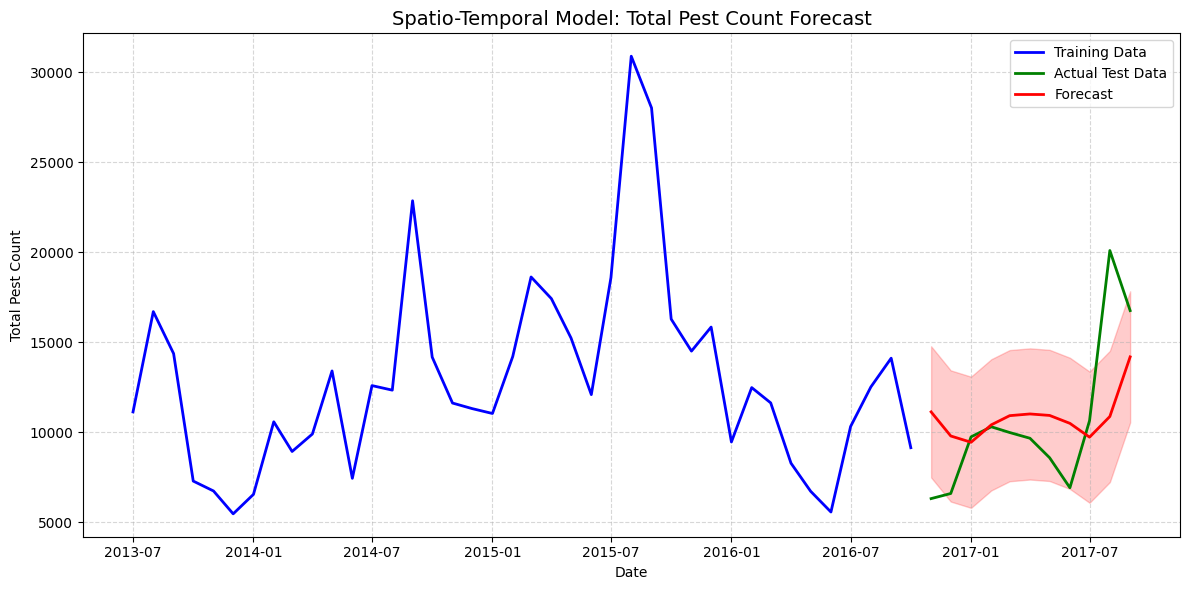

In [22]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,6))

# Training data
plt.plot(train_dates,
         train_total,
         label='Training Data',
         color='blue',
         linewidth=2)

# Actual test
plt.plot(test_dates,
         total_actual,
         label='Actual Test Data',
         color='green',
         linewidth=2)

# Predicted test
plt.plot(test_dates,
         total_pred,
         label='Forecast',
         color='red',
         linewidth=2)

# Confidence band (approximate)
error_std = np.std(total_actual - total_pred)

plt.fill_between(test_dates,
                 total_pred - error_std,
                 total_pred + error_std,
                 color='red',
                 alpha=0.2)

plt.title("Spatio-Temporal Model: Total Pest Count Forecast", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Total Pest Count")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

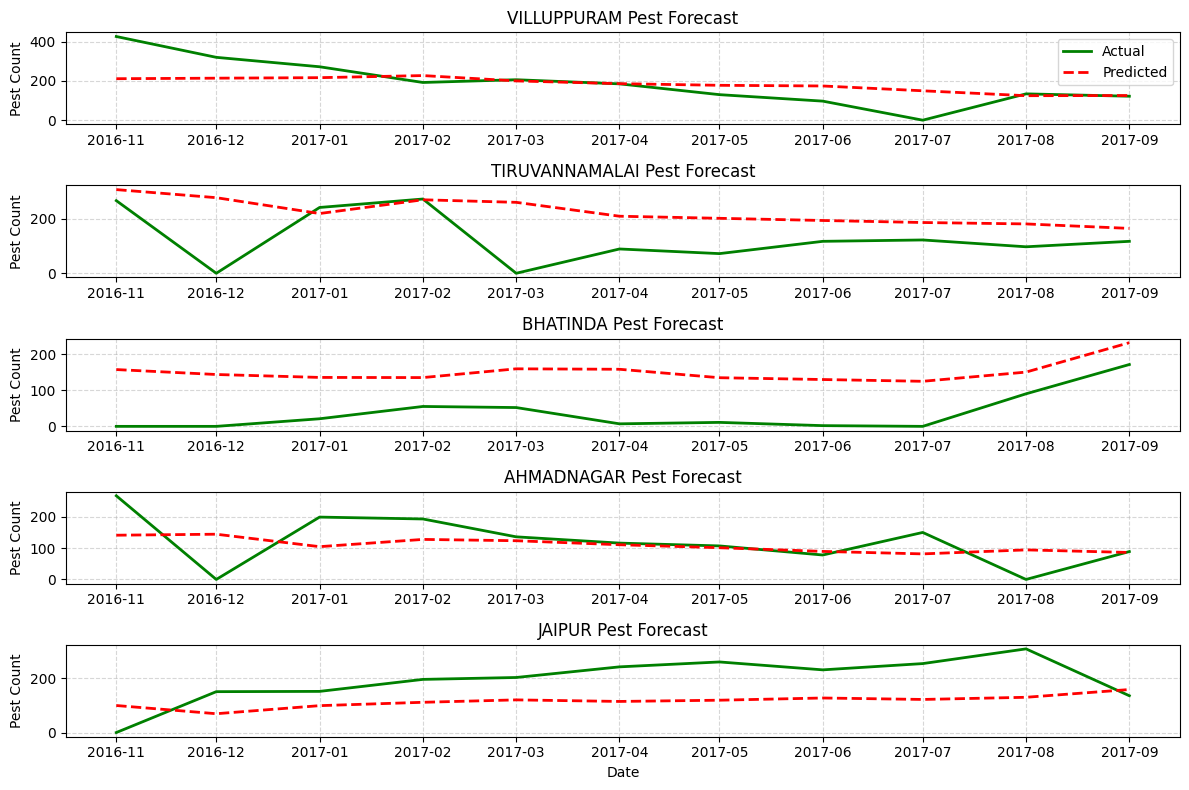

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Number of districts to plot
num_plot = 5

# Select districts with highest total pest counts
top_district_idx = pivot_df.sum().sort_values(ascending=False).index[:num_plot]

plt.figure(figsize=(12,8))

for i, district in enumerate(top_district_idx):

    d_idx = pivot_df.columns.get_loc(district)

    actual_d = actual_full[:, d_idx]
    pred_d   = pred_full[:, d_idx]

    plt.subplot(num_plot,1,i+1)

    plt.plot(test_dates, actual_d, label='Actual', color='green', linewidth=2)
    plt.plot(test_dates, pred_d, label='Predicted', color='red', linestyle='--', linewidth=2)

    plt.title(f"{district} Pest Forecast")
    plt.ylabel("Pest Count")
    plt.grid(True, linestyle="--", alpha=0.5)

    if i == 0:
        plt.legend()

plt.xlabel("Date")
plt.tight_layout()
plt.show()

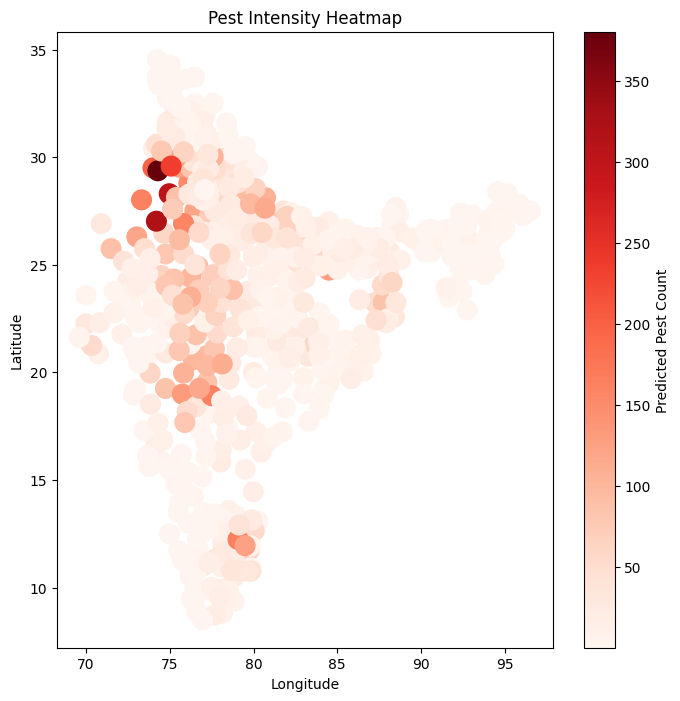

In [24]:
import matplotlib.pyplot as plt

district_pred = pd.DataFrame({
    "district": pivot_df.columns,
    "pest_pred": pred_full[-1]
})

district_coords = df_monthly[['district','latitude','longitude']].drop_duplicates().reset_index(drop=True)

heatmap_data = district_coords.merge(district_pred,on="district")

plt.figure(figsize=(8,8))

plt.scatter(
    heatmap_data["longitude"],
    heatmap_data["latitude"],
    c=heatmap_data["pest_pred"],
    cmap="Reds",
    s=200
)

plt.colorbar(label="Predicted Pest Count")
plt.title("Pest Intensity Heatmap")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()